# Case Study 2: Credit Card Fraud Detection

## Objective
Predict whether an online transaction is **genuine or fraudulent** using **XGBoost** on the real IEEE-CIS Fraud Detection dataset.

The case study focuses on:
- Severe class imbalance
- SMOTE oversampling
- Decision-threshold tuning
- ROC-AUC, precision, recall and F1-score
- XGBoost feature importance


In [4]:
# Install required libraries
!pip install -q xgboost imbalanced-learn


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

np.random.seed(42)


## 1. Dataset

This notebook uses the **IEEE-CIS Fraud Detection** dataset from Kaggle.

Download `train_transaction.csv` from the Kaggle competition and upload it to Colab/Jupyter, or place it in the same folder as this notebook.

The competition's target variable is `isFraud`. The original training data contains about 590,000 transactions and is strongly imbalanced, with fraudulent transactions forming only a small minority.

For faster execution in a student/Colab environment, this notebook uses a **stratified sample of 150,000 rows** from the real training dataset.

The raw Kaggle dataset should **not** be uploaded to GitHub because it is very large and subject to the competition's rules.


In [6]:
# Load the real IEEE-CIS transaction dataset
df = pd.read_csv("train_transaction.csv")

print("Original dataset shape:", df.shape)
print("Fraud distribution:")
print(df["isFraud"].value_counts())
print("\nFraud percentage:")
print((df["isFraud"].value_counts(normalize=True) * 100).round(2))


Original dataset shape: (22881, 394)
Fraud distribution:
isFraud
0    22236
1      645
Name: count, dtype: int64

Fraud percentage:
isFraud
0    97.18
1     2.82
Name: proportion, dtype: float64


In [7]:
# Stratified sample for faster model training
sample_size = min(150000, len(df))

fraud_df = df[df["isFraud"] == 1]
genuine_df = df[df["isFraud"] == 0]

fraud_fraction = len(fraud_df) / len(df)
sample_fraud = max(1, int(sample_size * fraud_fraction))
sample_genuine = sample_size - sample_fraud

df = pd.concat([
    fraud_df.sample(n=min(sample_fraud, len(fraud_df)), random_state=42),
    genuine_df.sample(n=min(sample_genuine, len(genuine_df)), random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Working dataset shape:", df.shape)
print(df["isFraud"].value_counts())


Working dataset shape: (22881, 394)
isFraud
0    22236
1      645
Name: count, dtype: int64


## 2. Feature Selection

A small set of transaction-level numeric features is used so the case study remains practical to run.

These include transaction amount, time, card attributes, address information, distance, and transaction-count features. The meanings of many IEEE-CIS variables are anonymized by the dataset provider.


In [8]:
selected_features = [
    "TransactionDT",
    "TransactionAmt",
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2",
    "dist1",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "C7",
    "C8",
    "C9",
    "C10",
    "C11",
    "C12",
    "C13",
    "C14"
]

available_features = [c for c in selected_features if c in df.columns]

X = df[available_features].copy()
y = df["isFraud"].astype(int)

print("Number of features:", len(available_features))
print("Features:", available_features)


Number of features: 23
Features: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [9]:
# Handle missing numeric values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("Remaining missing values:", X.isnull().sum().sum())


Remaining missing values: 0


## 3. Train-Test Split

SMOTE is applied **only to the training data**. The test set keeps the original class distribution so that evaluation reflects the real imbalanced problem.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining class distribution before SMOTE:")
print(y_train.value_counts())


Training samples: 18304
Testing samples: 4577

Training class distribution before SMOTE:
isFraud
0    17788
1      516
Name: count, dtype: int64


## 4. SMOTE Oversampling

SMOTE creates synthetic minority-class examples to reduce the effect of class imbalance during training.


In [11]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
isFraud
0    17788
1      516
Name: count, dtype: int64

After SMOTE:
isFraud
0    17788
1    17788
Name: count, dtype: int64


## 5. XGBoost Model

XGBoost is used as the main fraud-classification model.


In [12]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


## 6. ROC-AUC Evaluation


In [13]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 4))


ROC-AUC: 0.8341


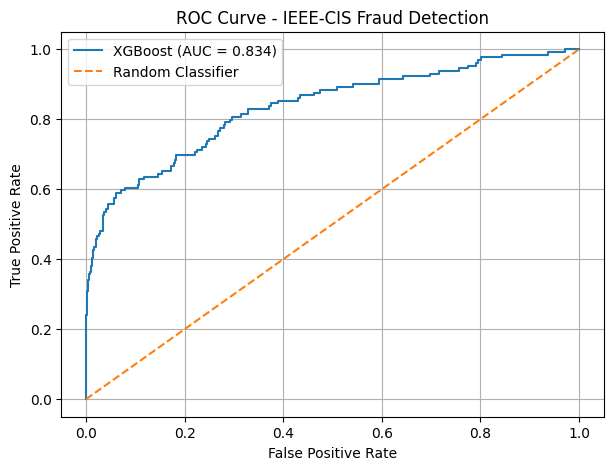

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - IEEE-CIS Fraud Detection")
plt.legend()
plt.grid()
plt.show()


## 7. Evaluation at the Default Threshold (0.50)


In [15]:
threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

print("Classification Report at Threshold 0.50:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Classification Report at Threshold 0.50:
              precision    recall  f1-score   support

     Genuine       0.98      0.99      0.99      4448
       Fraud       0.49      0.39      0.43       129

    accuracy                           0.97      4577
   macro avg       0.73      0.69      0.71      4577
weighted avg       0.97      0.97      0.97      4577

Confusion Matrix:
[[4395   53]
 [  79   50]]


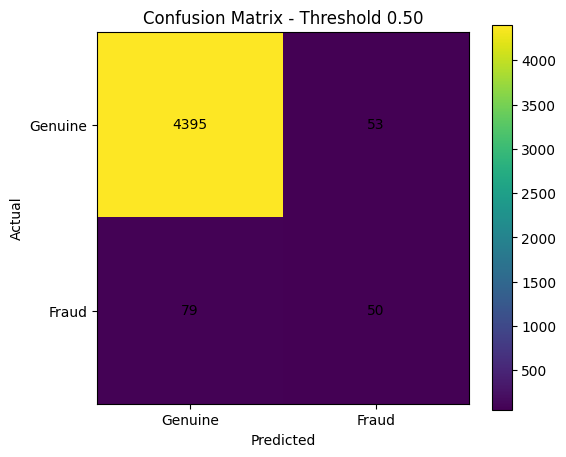

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.xticks([0, 1], ["Genuine", "Fraud"])
plt.yticks([0, 1], ["Genuine", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Threshold 0.50")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 8. Decision Threshold Tuning

A default threshold of 0.50 is not necessarily appropriate for fraud detection. Lowering the threshold can detect more fraudulent transactions, but may also increase false alarms.

The following thresholds are compared using precision, recall and F1-score.


In [17]:
thresholds_to_test = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1_score": f1_score(y_test, predictions, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))


   threshold  precision  recall  f1_score  false_positives  false_negatives
0        0.5     0.4854  0.3876    0.4310               53               79
1        0.4     0.3448  0.4651    0.3960              114               69
2        0.3     0.2376  0.5581    0.3333              231               57
3        0.2     0.1429  0.6047    0.2311              468               51
4        0.1     0.0816  0.7132    0.1464             1036               37


In [18]:
# Search for the threshold with the highest F1-score
all_thresholds = np.arange(0.05, 0.96, 0.05)
tuning_results = []

for threshold in all_thresholds:
    predictions = (y_prob >= threshold).astype(int)

    tuning_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1_score": f1_score(y_test, predictions, zero_division=0)
    })

tuning_df = pd.DataFrame(tuning_results)
best_threshold = float(
    tuning_df.loc[tuning_df["f1_score"].idxmax(), "threshold"]
)

print("Best threshold by F1-score:", best_threshold)
print(tuning_df.round(4))


Best threshold by F1-score: 0.65
    threshold  precision  recall  f1_score
0        0.05     0.0581  0.8527    0.1088
1        0.10     0.0816  0.7132    0.1464
2        0.15     0.1122  0.6434    0.1910
3        0.20     0.1429  0.6047    0.2311
4        0.25     0.1935  0.5969    0.2922
5        0.30     0.2376  0.5581    0.3333
6        0.35     0.2957  0.5271    0.3788
7        0.40     0.3448  0.4651    0.3960
8        0.45     0.4000  0.4341    0.4164
9        0.50     0.4854  0.3876    0.4310
10       0.55     0.5679  0.3566    0.4381
11       0.60     0.6377  0.3411    0.4444
12       0.65     0.6984  0.3411    0.4583
13       0.70     0.7143  0.3101    0.4324
14       0.75     0.7778  0.2713    0.4023
15       0.80     0.8611  0.2403    0.3758
16       0.85     0.9200  0.1783    0.2987
17       0.90     0.9412  0.1240    0.2192
18       0.95     0.9286  0.1008    0.1818


In [19]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(f"Final Classification Report at threshold {best_threshold:.2f}:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Final Confusion Matrix:")
print(cm_tuned)


Final Classification Report at threshold 0.65:
              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      4448
       Fraud       0.70      0.34      0.46       129

    accuracy                           0.98      4577
   macro avg       0.84      0.67      0.72      4577
weighted avg       0.97      0.98      0.97      4577

Final Confusion Matrix:
[[4429   19]
 [  85   44]]


## 9. Feature Importance

XGBoost provides feature importance scores that show which input variables contributed most to the model's predictions.

These scores indicate model usage, not causal relationships.


In [20]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 10 Important Features:")
print(importance_df.head(10))


Top 10 Important Features:
           feature  importance
12              C4    0.248609
4            card3    0.141668
10              C2    0.113323
13              C5    0.105681
19             C11    0.042736
9               C1    0.037263
14              C6    0.034556
22             C14    0.034446
17              C9    0.033741
1   TransactionAmt    0.029013


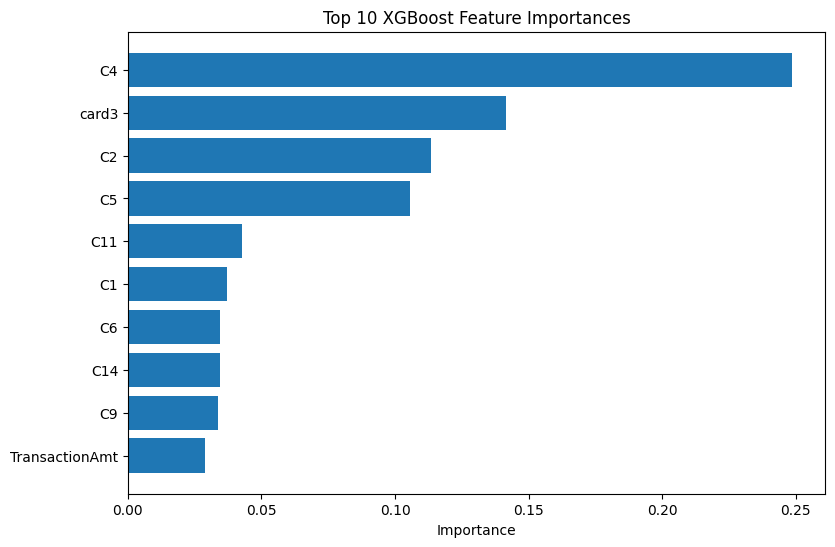

In [21]:
top = importance_df.head(10)

plt.figure(figsize=(9, 6))
plt.barh(
    top["feature"][::-1],
    top["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.show()


## 10. Conclusion

The IEEE-CIS transaction dataset is a strongly imbalanced fraud-detection problem. XGBoost was trained after applying SMOTE to the training data.

ROC-AUC, precision, recall and F1-score were used instead of relying only on accuracy. Decision-threshold tuning demonstrated the trade-off between detecting more fraudulent transactions and generating more false alerts.

A **false negative** is a fraudulent transaction predicted as genuine, which can directly contribute to financial loss. A **false positive** is a genuine transaction incorrectly flagged as fraud, which can inconvenience customers and create additional review workload.

The final threshold is selected using **F1-score** in this educational case study. In a real financial system, the threshold should instead be selected using validated fraud-loss and customer-impact costs.

Feature importance scores were also extracted from XGBoost to identify the variables most used by the model.


In [24]:

threshold_df.to_csv("threshold_results.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)

print("Results saved successfully.")


Results saved successfully.
